# EIS Simulation

Electrochemical Impedance Spectroscopy (EIS) is a technique for characterising
battery dynamics by applying a small sinusoidal perturbation at different
frequencies and measuring the resulting impedance. PyBaMM provides
`EISSimulation`, a frequency-domain solver that computes impedance spectra
directly — much faster than running full time-domain simulations at each
frequency.

In this notebook we will:
1. Run a basic EIS simulation and inspect the solution
2. Access and plot impedance data (Nyquist plots)
3. Compare impedance at different states of charge (SOC)
4. Compare impedance across different models
5. Save EIS data to file

In [ ]:
%pip install "pybamm[plot,cite]" -q    # install PyBaMM if it is not installed
import matplotlib.pyplot as plt
import numpy as np

import pybamm

## Running a basic EIS simulation

To run an EIS simulation we need a model with the `"surface form"` option set
to `"differential"`. We pass the model to `pybamm.EISSimulation`, define the
frequencies of interest, and call `solve`:

In [2]:
model = pybamm.lithium_ion.SPM(options={"surface form": "differential"})
eis_sim = pybamm.EISSimulation(model)

frequencies = np.logspace(-4, 4, 30)  # 10^-4 to 10^4 Hz
result = eis_sim.solve(frequencies)
result

The `solve` method returns an `EISSolution` object. Like the time-series
`Solution`, it is also a `SolutionBase` instance, stores timing information,
and is accessible via the `solution` property on the simulation — the same
pattern as `Simulation.solution`:

In [3]:
print(f"isinstance EISSolution:  {isinstance(result, pybamm.EISSolution)}")
print(f"isinstance SolutionBase: {isinstance(result, pybamm.SolutionBase)}")
print(f"Set-up time: {result.set_up_time}")
print(f"Solve time:  {result.solve_time}")
print(f"Same as eis_sim.solution: {result is eis_sim.solution}")

isinstance EISSolution:  True
isinstance SolutionBase: True
Set-up time: 8.201 ms
Solve time:  61.040 ms
Same as eis_sim.solution: True


## Accessing solution data

The `EISSolution` supports dict-style access, just like the time-series
`Solution`. You can use `result["Variable name"]` to get data arrays:

In [4]:
# Dict-style access — same API as Solution
print("Frequencies (Hz):\n", result["Frequency [Hz]"])
print("\nComplex impedance:\n", result["Impedance [Ohm]"])
print("\nReal part:\n", result["Z_re [Ohm]"])
print("\nImaginary part:\n", result["Z_im [Ohm]"])

# Convenience properties also available
print("\nVia property:", result.impedance[:3], "...")

Frequencies (Hz):
 [1.00000000e-04 1.88739182e-04 3.56224789e-04 6.72335754e-04
 1.26896100e-03 2.39502662e-03 4.52035366e-03 8.53167852e-03
 1.61026203e-02 3.03919538e-02 5.73615251e-02 1.08263673e-01
 2.04335972e-01 3.85662042e-01 7.27895384e-01 1.37382380e+00
 2.59294380e+00 4.89390092e+00 9.23670857e+00 1.74332882e+01
 3.29034456e+01 6.21016942e+01 1.17210230e+02 2.21221629e+02
 4.17531894e+02 7.88046282e+02 1.48735211e+03 2.80721620e+03
 5.29831691e+03 1.00000000e+04]

Complex impedance:
 [1.00563333e-01-0.18918861j 1.00541067e-01-0.10051692j
 1.00465109e-01-0.05376932j 1.00228638e-01-0.02937809j
 9.96259133e-02-0.01692566j 9.84603512e-02-0.01065627j
 9.68969090e-02-0.00720148j 9.54832027e-02-0.00501148j
 9.43678954e-02-0.00360485j 9.34972143e-02-0.00270308j
 9.28238758e-02-0.0021521j  9.23232216e-02-0.00190189j
 9.19865376e-02-0.00202381j 9.17769471e-02-0.00275431j
 9.15614093e-02-0.00454072j 9.10077709e-02-0.00815556j
 8.91552787e-02-0.01487124j 8.31767712e-02-0.02598032j
 6.740

## Nyquist plots

The standard way to visualise EIS data is a Nyquist plot, which shows the
real part of impedance on the x-axis and the negative imaginary part on the
y-axis. `EISSolution` has a built-in method for this:

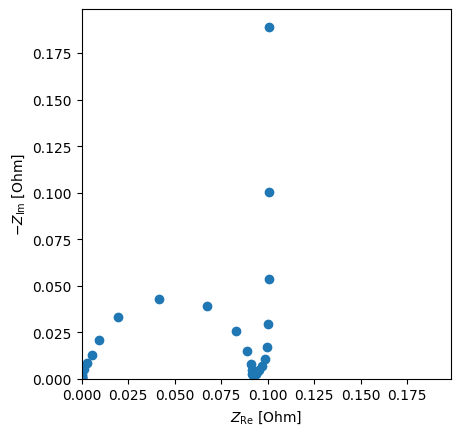

In [5]:
result.nyquist_plot(show_plot=False)
plt.show()

You can also build custom plots directly from the solution data:

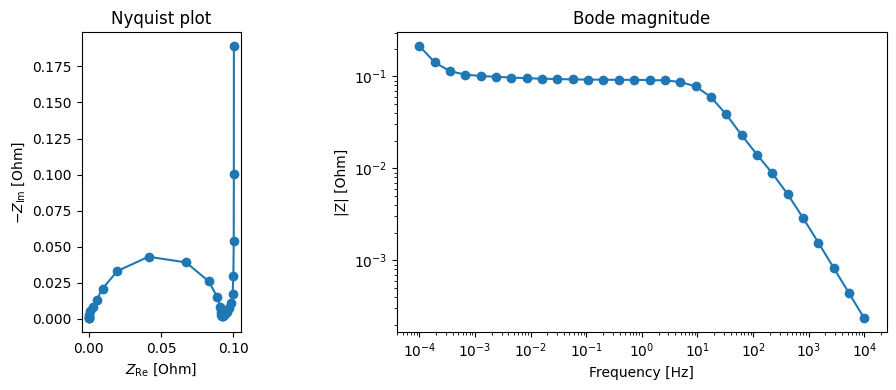

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Nyquist plot from dict-style access
axes[0].plot(result["Z_re [Ohm]"], -result["Z_im [Ohm]"], "o-")
axes[0].set_xlabel(r"$Z_\mathrm{Re}$ [Ohm]")
axes[0].set_ylabel(r"$-Z_\mathrm{Im}$ [Ohm]")
axes[0].set_title("Nyquist plot")
axes[0].set_aspect("equal")

# Bode-style: magnitude vs frequency
Z = result["Impedance [Ohm]"]
axes[1].loglog(result["Frequency [Hz]"], np.abs(Z), "o-")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|Z| [Ohm]")
axes[1].set_title("Bode magnitude")

fig.tight_layout()
plt.show()

## SOC sweep

Battery impedance changes with the state of charge. We can sweep SOC by
passing `initial_soc` to `solve`:

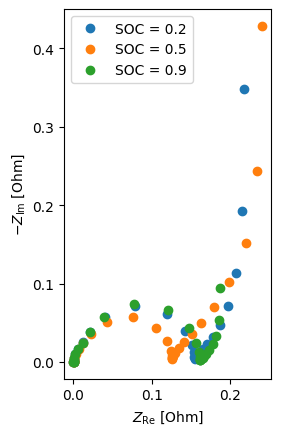

In [7]:
model = pybamm.lithium_ion.SPM(options={"surface form": "differential"})
parameter_values = pybamm.ParameterValues("Chen2020")
eis_sim = pybamm.EISSimulation(model, parameter_values=parameter_values)

frequencies = np.logspace(-4, 4, 30)
_, ax = plt.subplots()

for soc in [0.2, 0.5, 0.9]:
    result = eis_sim.solve(frequencies, initial_soc=soc)
    ax.plot(
        result["Z_re [Ohm]"],
        -result["Z_im [Ohm]"],
        "o",
        label=f"SOC = {soc}",
    )

ax.set_xlabel(r"$Z_\mathrm{Re}$ [Ohm]")
ax.set_ylabel(r"$-Z_\mathrm{Im}$ [Ohm]")
ax.set_aspect("equal")
ax.legend()
plt.show()

## Comparing models

We can compare the impedance predicted by different electrochemical models.
All models must use `"surface form": "differential"` for EIS:

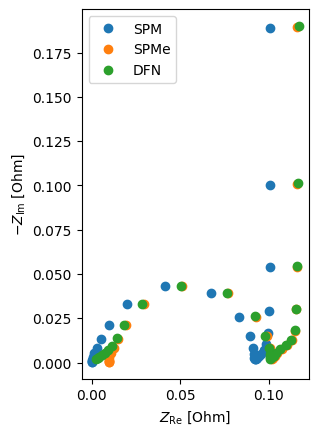

In [8]:
models = {
    "SPM": pybamm.lithium_ion.SPM(options={"surface form": "differential"}),
    "SPMe": pybamm.lithium_ion.SPMe(options={"surface form": "differential"}),
    "DFN": pybamm.lithium_ion.DFN(options={"surface form": "differential"}),
}

frequencies = np.logspace(-4, 4, 30)
_, ax = plt.subplots()

for name, model in models.items():
    eis_sim = pybamm.EISSimulation(model)
    result = eis_sim.solve(frequencies)
    ax.plot(
        result["Z_re [Ohm]"],
        -result["Z_im [Ohm]"],
        "o",
        label=name,
    )

ax.set_xlabel(r"$Z_\mathrm{Re}$ [Ohm]")
ax.set_ylabel(r"$-Z_\mathrm{Im}$ [Ohm]")
ax.set_aspect("equal")
ax.legend()
plt.show()

## Saving EIS data

The `EISSolution` supports saving data in several formats. The `data`
property gives a dict-like view of all variables (same interface as
`Solution.data`):

In [9]:
# .data returns a dict-like view, .get_data_dict() returns a plain dict for export
print("Keys in data:", list(result.data.keys()))
result.get_data_dict()

Keys in data: ['Frequency [Hz]', 'Impedance [Ohm]', 'Z_re [Ohm]', 'Z_im [Ohm]']


{'Frequency [Hz]': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
        1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
        1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
        2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
        2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
        3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
        4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
        5.29831691e+03, 1.00000000e+04]),
 'Z_re [Ohm]': array([0.11670175, 0.11623164, 0.11578165, 0.11531082, 0.11442335,
        0.11262009, 0.10968718, 0.10644623, 0.10408134, 0.1026827 ,
        0.10180478, 0.10121347, 0.10083789, 0.10061397, 0.1003949 ,
        0.09984292, 0.09799588, 0.09202418, 0.0762611 , 0.05023747,
        0.02856141, 0.01836863, 0.01412147, 0.01138017, 0.00918837,
        0.0072826 , 0.00549163, 0.00416697, 0.00322355, 0.00252515]),
 'Z_im [Ohm]

Save to CSV or JSON:

In [10]:
result.save_data("eis_data.csv", to_format="csv")
result.save_data("eis_data.json", to_format="json")

Save the entire solution object using pickle (can be reloaded with
`pybamm.load`):

In [11]:
result.save("eis_solution.pkl")
loaded = pybamm.load("eis_solution.pkl")
print("Loaded frequencies:", loaded.frequencies[:5], "...")
print("Loaded impedance: ", loaded.impedance[:5], "...")

Loaded frequencies: [0.0001     0.00018874 0.00035622 0.00067234 0.00126896] ...
Loaded impedance:  [0.11670175-0.1899683j  0.11623164-0.10144159j 0.11578165-0.05469772j
 0.11531082-0.03043038j 0.11442335-0.01840321j] ...


Clean up the files we saved:

In [12]:
import os

os.remove("eis_data.csv")
os.remove("eis_data.json")
os.remove("eis_solution.pkl")

## References

The relevant papers for this notebook are:

In [13]:
pybamm.print_citations()

[1] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[2] Von DAG Bruggeman. Berechnung verschiedener physikalischer konstanten von heterogenen substanzen. i. dielektrizitätskonstanten und leitfähigkeiten der mischkörper aus isotropen substanzen. Annalen der physik, 416(7):636–664, 1935.
[3] Chang-Hui Chen, Ferran Brosa Planella, Kieran O'Regan, Dominika Gastol, W. Dhammika Widanage, and Emma Kendrick. Development of Experimental Techniques for Parameterization of Multi-scale Lithium-ion Battery Models. Journal of The Electrochemical Society, 167(8):080534, 2020. doi:10.1149/1945-7111/ab9050.
[4] Marc Doyle, Thomas F. Fuller, and John Newman. Modeling of galvanostatic charge and discharge of the lithium/polymer/insertion cell. Journal of the Electrochemical society, 140(6):1526–1533, 1993. 